# Gaming Toxicity Detection

**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward


In [67]:
# libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
import html as html_lib
from nltk.tokenize import TweetTokenizer


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import html as html_lib
from pathlib import Path
import os 
import spacy
nlp = spacy.load("en_core_web_sm")

# reproducibility
seed = 7524
np.random.seed(seed)

# remove limit at number of columns and rows shown
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# project root (notebooks/gaming/ -> notebooks/ -> project root)
PROJECT_ROOT = Path().resolve().parent.parent

In [4]:
# data directories
DATA_DIR_WOT  = PROJECT_ROOT / "data/processed_data/wot/"
DATA_DIR_DOTA = PROJECT_ROOT / "data/processed_data/dota/"

## World of Tanks

In [7]:
# read parquet file
wot = pd.read_parquet(DATA_DIR_WOT / "wot.parquet")
# check 
print(f"Dataset shape: {wot.shape}")
print(f"Dataset first 5 rows:\n{wot.head(5)}\n")
print(f"Dataset info:")
wot.info()


Dataset shape: (53701, 3)
Dataset first 5 rows:
   index                        message  label
0  30702                        no rush    0.0
1  18607  whatever ... watch the replay    0.0
2  32901                        useless    1.0
3  25964                      3 gunmark    0.0
4  28643                            lol    0.0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53701 entries, 0 to 53700
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    53701 non-null  int64  
 1   message  53701 non-null  object 
 2   label    53701 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ MB


### Exploratory Data Analysis (EDA)

| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

#### Duplicates

In [8]:
# look at dataset with duplicates 
wot_dup = wot[wot.duplicated(subset="message", keep=False)].sort_values("message")
# look at some examples
wot_dup.head(10)

,index,message,label
47060,40582,!,0.0
15393,31613,!,0.0
43008,6872,!,0.0
29884,39948,!!!!,0.0
36108,32907,!!!!,0.0
49234,1278,!!!!,0.0
10230,16596,#,0.0
12496,8848,#,0.0
7901,36404,#ERROR!,0.0
43495,46037,#ERROR!,0.0


In [9]:
# top 100 duplicated messages
wot_dup["message"].value_counts(ascending=False).head(100)

message
gg                   3188
lol                   458
nice                  396
gj                    315
wtf                   201
cap                   190
arty                  183
thx                   175
#ERROR!               171
ok                    169
omg                   161
GG                    149
sry                   149
idiot                 124
go                    121
yes                   117
spot                  114
wow                   113
?                     113
ty                    108
:)                    106
idiots                 99
xd                     95
:D                     86
ns                     80
sorry                  79
...                    78
gl                     74
ffs                    66
move                   65
ggs                    63
no                     63
wp                     62
xD                     59
Im Spotted at E5!      59
all good?              57
Im Spotted at E6!      53
pls                    53
good

Most of these duplicates are useful and important data to train or models for detecting toxicity. We need to check for same messages but different labels.

In [10]:
# Look for duplicates with same messages but different labels
conflicts = wot.groupby("message")["label"].nunique()
conflicts = conflicts[conflicts > 1]

print(f"Messages with conflicting labels: {len(conflicts)}")
conflict_rows = wot[wot["message"].isin(conflicts.index)].sort_values("message")

# Check how large is the proportion of conflicting duplicates
conflict_pct = len(conflict_rows) / len(wot) * 100
print(f"Proportion of messages with conflicting labels: {conflict_pct:.2f}%")
print(f"Number of messages with conflicting labels: {len(conflict_rows)}")

Messages with conflicting labels: 374
Proportion of messages with conflicting labels: 13.94%
Number of messages with conflicting labels: 7484


These messages can not be used for analysis, since it is a problem of `annotation`. Using them will be equal to guessing. Duplicated rows account for 14% of the data, which is a huge loss but we can not use that.

In [11]:
# drop conflicting messages
wot = wot[~wot["message"].isin(conflicts.index)].reset_index(drop=True)
print(wot.shape)

(46217, 3)


In [12]:
# check for any conflicting duplicates remaining
conflicts_after = wot.groupby("message")["label"].nunique()
conflicts_after = conflicts_after[conflicts_after > 1]
print(f"Conflicting messages remaining after removal: {len(conflicts_after)}")

Conflicting messages remaining after removal: 0


#### Class distribution

In [13]:
# Class balance check
print(f"Class distribution:\n{wot['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{wot['label'].value_counts(normalize=True)}")

Class distribution:
label
0.0    37421
1.0     6594
2.0     1772
3.0      334
4.0       70
5.0       26
Name: count, dtype: int64

Class distribution (normalized):
label
0.0    0.809680
1.0    0.142675
2.0    0.038341
3.0    0.007227
4.0    0.001515
5.0    0.000563
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_33660\3772814331.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\nyuss\AppData\Local\Temp\ipykernel_33660\3772814331.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


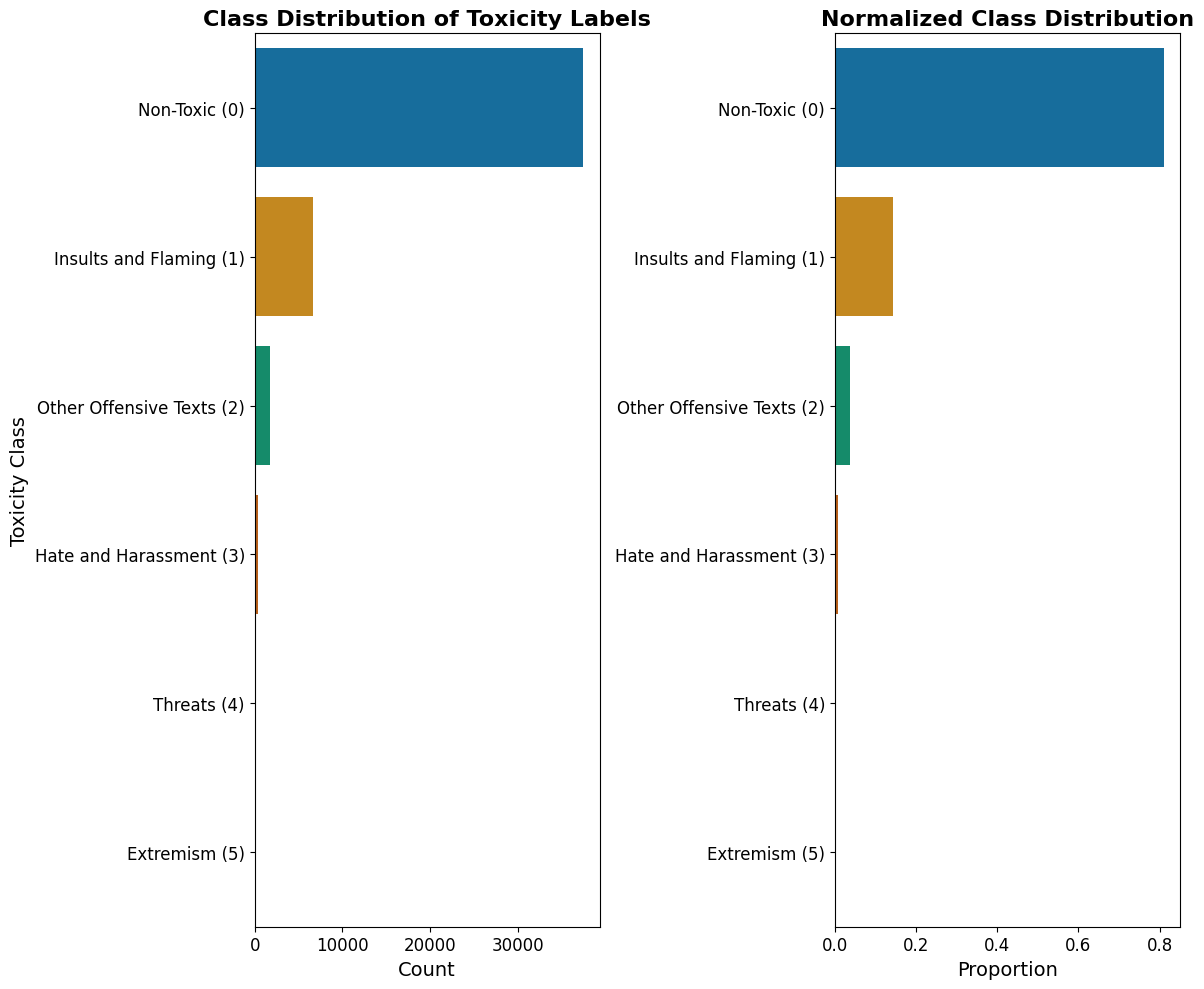

In [18]:
# Class balance plot + normalized class balance plot side by side

# class order and readable labels
class_order = [0, 1, 2, 3, 4, 5]
class_labels = [
    "Non-Toxic (0)",
    "Insults and Flaming (1)",
    "Other Offensive Texts (2)",
    "Hate and Harassment (3)",
    "Threats (4)",
    "Extremism (5)"
]

# map numeric labels to readable names
label_map = dict(zip(class_order, class_labels))
wot["label_name"] = wot["label"].map(label_map)

# normalized proportions
class_props = (
    wot["label"]
    .value_counts(normalize=True)
    .reindex(class_order)
)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# raw counts plot
sns.countplot(
    y="label_name",
    data=wot,
    order=class_labels,
    palette="colorblind",
    ax=axes[0]
)

# aesthetics
# title 
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=16)

# axis labels and ticks
axes[0].set_xlabel("Count", fontsize=14)
axes[0].set_ylabel("Toxicity Class", fontsize=14)

axes[0].tick_params(axis="y", labelsize=12)
axes[0].tick_params(axis="x", labelsize=12)


# normalized distribution
sns.barplot(
    x=class_props.values,
    y=class_labels,
    palette="colorblind",
    ax=axes[1]
)

# aesthetics 
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=16)

# axis labels and ticks 
axes[1].set_xlabel("Proportion", fontsize=14)

axes[1].tick_params(axis="y", labelsize=12)
axes[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

That gives us the idea that the class proportions are very imbalanced. We might experiment with binary vs multiclass classification later because of that. We could also merge minority labels to make it easier for model to learn data signals.

#### Non-English Messages

In [29]:
# quantify non-ASCII messages (non-english)
non_english_count = wot["message"].str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum()


print(f"Number of non-ASCII messages: {non_english_count}")
print(f"Percentage of non-ASCII messages: {(non_english_count / len(wot)) * 100:.2f}%")

Number of non-ASCII messages: 4502
Percentage of non-ASCII messages: 9.74%


We need to drop that since we are predicting on English words only.

In [30]:
# english dataset
wot_english = wot[~wot["message"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)].copy()

# information
print(f"Shape of english-only dataset:{wot_english.shape}\n")
print(f"Information about the dataset:{wot_english.info()}\n")

Shape of english-only dataset:(41715, 5)

<class 'pandas.core.frame.DataFrame'>
Index: 41715 entries, 0 to 46215
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           41715 non-null  int64  
 1   message         41715 non-null  object 
 2   label           41715 non-null  float64
 3   label_name      41715 non-null  object 
 4   comment_length  41715 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.9+ MB
Information about the dataset:None



#### Data Artifacts

In [31]:
# #ERROR! entries
error_count = wot["message"].str.contains(r"#ERROR!", regex=False, na=False).sum()
print(f"#ERROR! messages: {error_count}")

# HTML entities
html_mask = wot_english["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities: {html_mask.sum()}")
wot_english[html_mask][["message", "label"]].head(10)

#ERROR! messages: 0
Messages with HTML entities: 136


,message,label
21,&lt;#,0.0
119,&gt;bz,0.0
270,&lt;3,0.0
353,&lt;3,0.0
420,I've gotten all city maps today so I was like ...,0.0
1136,tog &amp; roll !! ladies,0.0
1497,&quot;_),0.0
2526,&lt;3,0.0
2581,&lt;3,0.0
2961,LAG&gt;,0.0


In [32]:
# drop #ERROR! rows
wot_english = wot_english[~wot_english["message"].str.contains(r"#ERROR!", regex=False, na=False)].reset_index(drop=True)

# decode HTML entities inline
wot_english["message"] = wot_english["message"].apply(html_lib.unescape)

print(f"Shape after artifact removal: {wot_english.shape}")
# HTML entities
html_mask = wot_english["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities: {html_mask.sum()}")
wot_english[html_mask][["message", "label"]].head(10)

Shape after artifact removal: (41715, 5)
Messages with HTML entities: 0


,message,label


In [33]:
# check decoded messages 
wot_english.loc[[21, 119, 270, 353, 420, 1136, 
                 1497, 2526, 2581, 2961], ["message", "label"]]

,message,label
21,should i cap,0.0
119,tx,0.0
270,scorp,0.0
353,arta rdy,0.0
420,but iam not,0.0
1136,GG,0.0
1497,gj,0.0
2526,Im Spotted at K7!,0.0
2581,nice bro,0.0
2961,move,0.0


`#ERROR!` entries are spreadsheet import artifacts - they carry no linguistic content and would confuse any vectorizer. HTML entities like `&lt;` are encoding artifacts from the data collection pipeline; decoding them restores the original character so downstream tokenization sees real text instead of escape sequences.

#### Number of words per document

In [34]:
# splitting the dataset 

# features and target
X = wot_english["message"]
y = wot_english["label"]

# First split: 20% for final testing, 80% remains for training/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=7524, shuffle = True, stratify= y)

# datasets 
# train
train_df = pd.DataFrame({
    "message": X_train,
    "label": y_train
}).reset_index(drop=True)

# validation 
validation_df = pd.DataFrame({
    "message": X_val,
    "label": y_val
}).reset_index(drop=True)

# check shapes 
print(f"Train dataset shape:{train_df.shape}\n")
print(f"Validation dataset shape:{validation_df.shape}\n")

Train dataset shape:(33372, 2)

Validation dataset shape:(8343, 2)



In [35]:
# summary statistics of comments
print("Summary statistics of comment lengths:")

# create new column with comment world lengths
train_df["comment_length"] = train_df["message"].str.split().str.len()

# add median to summary statistics describe
train_describe = wot["comment_length"].describe()
train_describe 

Summary statistics of comment lengths:


count    46217.000000
mean         3.311422
std          2.590072
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         30.000000
Name: comment_length, dtype: float64

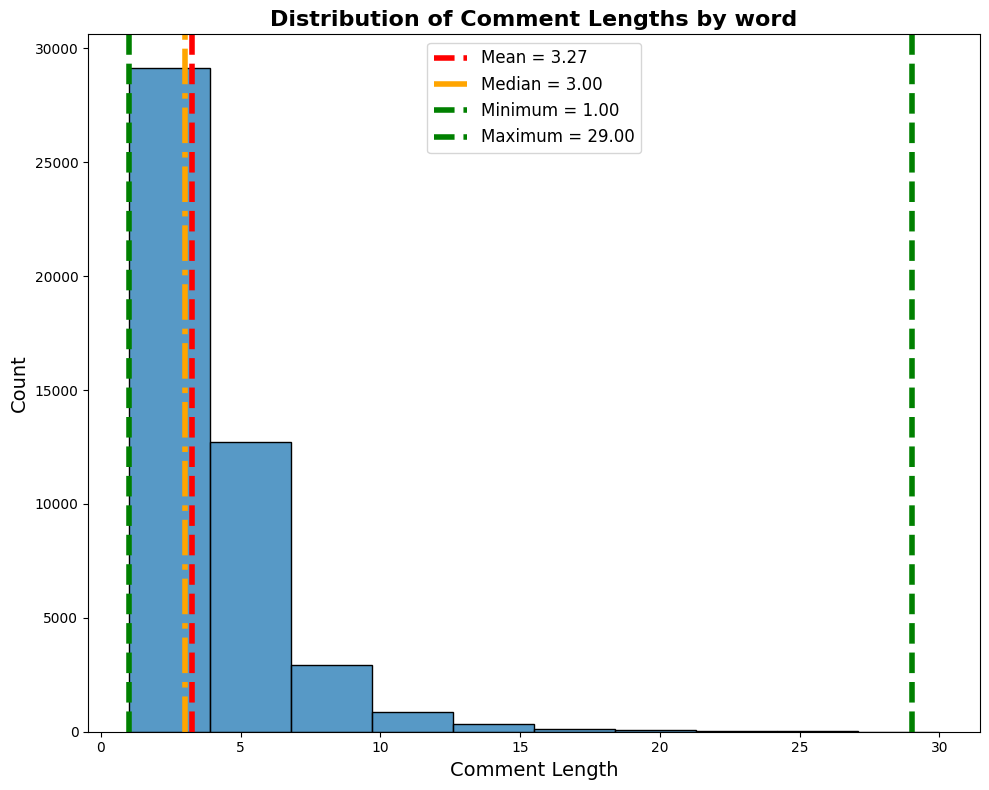

In [37]:
# distribution of world length 
# # summary statistics
mean_len = train_df["comment_length"].mean()
median_len = train_df["comment_length"].median()
min_len = train_df["comment_length"].min()
max_len = train_df["comment_length"].max()

# plot
plt.figure(figsize=(10, 8))

# histogram plot
sns.histplot(
    wot["comment_length"],
    bins=10,
    kde=False
)

# mean line
plt.axvline(
    mean_len,
    linestyle="--",
    linewidth=4,
    label=f"Mean = {mean_len:.2f}", 
    color = "red"
)

# median line
plt.axvline(
    median_len,
    linestyle="-.",
    linewidth=4,
    label=f"Median = {median_len:.2f}",
    color = "orange"
)

# min line 
plt.axvline(
    min_len,
    linestyle="--",
    linewidth=4,
    label=f"Minimum = {min_len:.2f}",
    color = "green"
)

# max line 
plt.axvline(
    max_len,
    linestyle="--",
    linewidth=4,
    label=f"Maximum = {max_len:.2f}",
    color = "green"
)

# title and labels
plt.title("Distribution of Comment Lengths by word", fontweight="bold", fontsize=16)

# xlabel
plt.xlabel("Comment Length", fontsize=14)

# ylabel
plt.ylabel("Count", fontsize=14)

# legend
plt.legend(fontsize=12)

# show the plot 
plt.tight_layout()
plt.show()

Messages are extremely short - median 3 words, max 29 in train data. Over 60% of messages are 1-3 words, confirming that gaming chat is reaction-driven rather than conversational. This justifies unigram + bigram TF-IDF: trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [38]:
# check messages 
# comments longer than the median top 10 words 
train_df[train_df["comment_length"] > median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
4,great.. computer crash... and now I am dead,8,0.0
15,i miss the friendly fire,5,0.0
19,who was spotting us,4,0.0
21,watch your back pus.y's,4,1.0
22,t100 somwhere like here,4,0.0
24,arty go for bling on challenger,6,0.0
27,ohhh... maybe go buy glass,5,0.0
28,no lights make it easy to win on this map,10,0.0
32,Im Spotted at G3!,4,0.0
36,all report LP for bot,5,1.0


In [39]:
# comments longer than the median bottom 10 words 
train_df[train_df["comment_length"] > median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
33346,haha arty shitted his pants,5,0.0
33347,its our game to lose,5,2.0
33351,theyre pushing this dside,4,0.0
33352,amd u done fuk all,5,1.0
33360,"Yanee77 (Leopard), you are blocking my target!",7,0.0
33361,sir is mean he made me play,7,0.0
33362,their arty is doing couonter battery,6,0.0
33363,704 is a problem though,5,0.0
33367,learn to play the fucking maps tards,7,1.0
33369,Im Spotted at G5!,4,0.0


This confirms that if we use `trigrams`, the model potentially might overfit to longer sentences without actually capturing the context.

In [40]:
# comments shoterter than the median top 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,gl all,2,0.0
1,yes,1,0.0
2,kinulo,1,0.0
3,*** fun,2,2.0
6,just cap,2,0.0
8,im scared,2,0.0
9,sry,1,0.0
11,pozz svima,2,0.0
13,im cuming,2,0.0
16,useless botchat,2,1.0


In [42]:
# comments shorter than the median bottom 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
33353,go behind,2,0.0
33354,finally,1,0.0
33355,thx,1,0.0
33356,Grille,1,0.0
33357,just cap,2,0.0
33358,he aint,2,0.0
33359,its clear,2,0.0
33364,centurion,1,0.0
33365,really e100,2,0.0
33370,krasava,1,0.0


#### Word Frequency analysis

In [43]:
# combine all messages
all_text = " ".join(X_train.astype(str))

# tokenize
words = all_text.split()

# frequency table
word_freq = pd.DataFrame(Counter(words).items(), 
                         columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)

# top 20
word_freq.head(20)

,word,count
91,at,1889
127,you,1786
90,Spotted,1579
89,Im,1566
37,the,1454
35,i,1317
63,go,1191
81,to,1121
94,is,1071
9,and,938


A lot of stop words, we might need to drop them later in pre-processing, since they do not reveal any contextual information. However we might need to think how to deal with stopwords which are part of the phrase, for example: `You` versus `Fuck you`.

In [170]:
# stopwords dictionary 
EXTRA = {
    # informal contractions sklearn misses
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve",

    # pure filler with no class signal
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "afk", "rng",
    "play", "game", "tank", "report", "spot",
    "today", "people", "kids", "nice", "sry", "team"

    # more fillers
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
     "elc", "ebr", "wg", "wot", "tier", "doing", "loose",

}   

# append with sklearn dictionary
STOPWORDS = list(ENGLISH_STOP_WORDS.union(EXTRA))
print(STOPWORDS)

['fifty', 'someone', 'spot', 'sometimes', 'why', 'out', 'hundred', 'yeah', 'report', 'thin', 'myself', 'wouldnt', 'own', 'along', 'per', 'has', 'whose', 'bill', 'also', 'formerly', 'together', 'often', 'line', 'theyre', 'gotta', 'here', 'fifteen', 'show', 'whenever', 'besides', 'sixty', 'how', 'below', 'their', 'still', 'into', 'have', 'twenty', 'must', 'seem', 'hereupon', 'first', 'anyone', 'beside', 'afterwards', 'un', 'doesnt', 'themselves', 'loose', 'back', 'nine', 'who', 'then', 'let', 'our', 'under', 'um', 'inc', 'left', 'whether', 'had', 'ever', 'because', 'and', 'across', 'five', 'always', 'enough', 'somehow', 'made', 'teamyes', 'those', 'eg', 'your', 'should', 'ours', 'other', 'him', 'much', 'gonna', 'latter', 'some', 'ten', 'whence', 'whither', 'are', 'another', 'while', 'whole', 'without', 'couldnt', 'thence', 'being', 'afk', 'twelve', 'becoming', 'weve', 'lol', 'do', 'come', 'she', 'you', 'dont', 'her', 'that', 'thus', 'when', 'find', 'serious', 'whereafter', 'for', 'with',

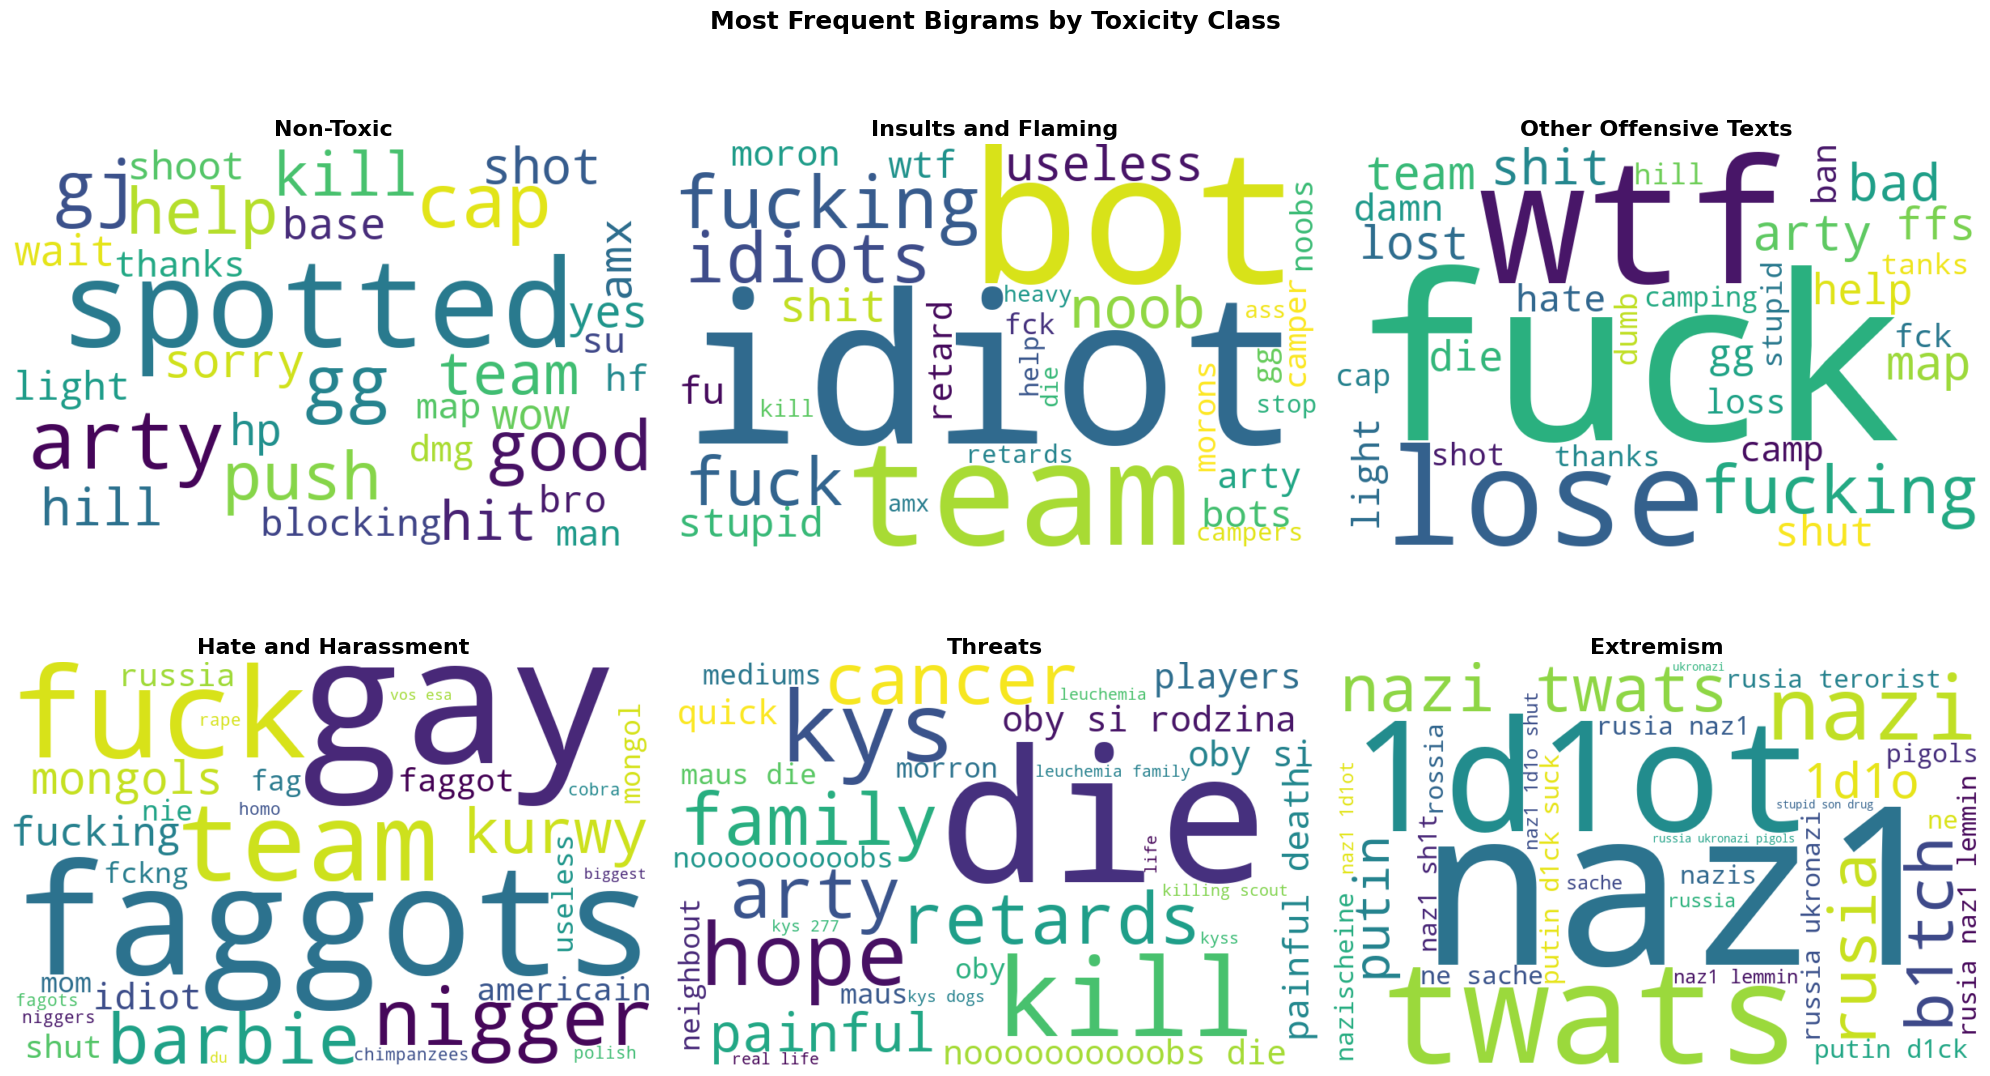

In [171]:
# class map
class_map = {
    0: "Non-Toxic",
    1: "Insults and Flaming",
    2: "Other Offensive Texts",
    3: "Hate and Harassment",
    4: "Threats",
    5: "Extremism"
}



# figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# create world clouds 
for i, cls in enumerate(sorted(train_df["label"].unique())):
    class_text = train_df.loc[train_df["label"] == cls, "message"].astype(str)
    
    # bigram vectorizer 
    bigram_vectorizer = CountVectorizer(
        # normalize accents
        strip_accents = "unicode", 
        # lowercase
        lowercase = True, 
        # stop words
        stop_words = STOPWORDS,
        max_df = 0.90,
        # ngram range
        ngram_range= (1, 3))
    
    
    # bigrams
    bigrams_trian = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_trian.sum(axis=0).A1
    bigram_names = bigram_vectorizer.get_feature_names_out()
    
    # bigrams frequency 
    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count": bigram_counts
    }).sort_values(by="count", ascending=False).head(30)
    

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], 
                                bigram_freq_train["count"]))
        
        # worcloud 
        wordcloud = WordCloud(
            width=800,
            height=500,
            background_color="white"
        ).generate_from_frequencies(bigram_dict)
        
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)

# design
plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Non-Toxic is coordination language, Insults attack skill, Hate attacks identity, Threats wish harm, Extremism uses leetspeak evasion.

- **Signals:**
    - Non-Toxic: spotted, cap, push, arty, gj, gg, help, hit - tactical coordination
    - Insults & Flaming: idiot, bot, noob, fucking, fuck, idiots, retard - skill-based attacks
    - Other Offensive: wtf, fuck, lose, fucking, shit, hate, camp - outcome frustration, no direct target
    - Hate & Harassment: faggots, nigger, gay, russia, mongols, americain -  identity-based slurs + ethnic targeting
    - Threats: die, kys, kill, cancer, family, retards, hope - explicit death wishes, harm to family
    - Extremism: nazi, naz1, twats, rusia, putin, terorist - political extremism + leetspeak evasion to bypass filters

### Pre-processing

| Feature | TweetTokenizer | Standard (split / CountVectorizer default) |
|---|---|---|
| Handles `@mentions`, `#hashtags` | Keeps as single token | Splits on `#`, `@` |
| Repeated chars (`looool`, `!!!!!!`) | Collapses to max 3 (`loool`, `!!!`) | Keeps full noise |
| Emoticons (`:)`, `:(`) | Preserved as tokens | Broken or dropped |
| Gaming shorthand (`gg`, `wtf`, `xD`) | Preserved as-is | Usually fine but no special handling |
| All-caps preservation | Configurable (`preserve_case`) | Not supported |
| Punctuation inside words | Handles intelligently | Often splits incorrectly |
| Informal language | Designed for it | Designed for formal text |

**Bottom line:** Gaming chat is structurally identical to Twitter - short, informal, abbreviation-heavy, emoticon-rich. TweetTokenizer was built for exactly this domain.


In [74]:
# tokenizer
tokenizer = TweetTokenizer(reduce_len = True, 
                           strip_handles = True)

# tokenize and clean tokens 
def tokenize(text):
    tokens = tokenizer.tokenize(text)
    tokens = [w if w.isupper() else w.lower() for w in tokens]
    tokens = [w for w in tokens if w not in STOPWORDS]
    return tokens

# function to clean text 
def batch_clean(texts):
    # step 1-3 for all messages
    all_tokens = [tokenize(t) for t in texts]
    
    # step 4: batch lemmatize with nlp.pipe
    joined = [" ".join(t) for t in all_tokens]
    results = []
    for doc, tokens in zip(nlp.pipe(joined, batch_size=256), all_tokens):
        upper = {w for w in tokens if w.isupper()}
        lemmas = [t.lemma_ if t.text not in upper else t.text for t in doc]
        lemmas = [w for w in lemmas if len(w) > 1 or w.isupper()]
        results.append(" ".join(lemmas))
    return results


In [76]:
# apply 
train_df["clean_message"] = batch_clean(train_df["message"].astype(str))
validation_df["clean_message"] = batch_clean(validation_df["message"].astype(str))

# print sample
print("Sample cleaned messages:")
train_df["clean_message"].head(10)

Sample cleaned messages:


0                                      
1                                   yes
2                                kinulo
3                                   fun
4    great .. computer crash ... I dead
5                            STA delete
6                                   cap
7                            alt f4 obv
8                                 scare
9                                      
Name: clean_message, dtype: object

All-caps words (`WTF`, `GG`, `NOOB`) carry expressive intensity in gaming - lowercasing them would lose that signal. Collapsing repeated punctuation reduces noise without removing the punctuation type itself.

#### Save Splits

In [79]:
# save splits to parquet 
train_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_train_ml.parquet", index=False)
validation_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_val_ml.parquet", index=False)


print("Saved:")
print(f"wot_train_ml.parquet — {train_df.shape}")
print(f"wot_val_ml.parquet - {validation_df.shape}")

Saved:
wot_train_ml.parquet — (33372, 4)
wot_val_ml.parquet - (8343, 3)


Three parquet files saved - one per split. 

## Dota 2 (CONDA)

In [86]:
# load Dota parquet
dota = pd.read_parquet(DATA_DIR_DOTA / "dota.parquet")
print(f"Dataset shape: {dota.shape}")
print(f"\nFirst 5 rows:\n{dota.head(5)}\n")
print(dota.info())

Dataset shape: (35887, 3)

First 5 rows:
   index  message  label
0  11263     wow!      0
1  13741      WTF      0
2  22125  wpe wpe      0
3   6453   hahaha      0
4   9644      wtf      0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    35887 non-null  int64 
 1   message  35887 non-null  object
 2   label    35887 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 841.2+ KB
None


### Exploratory Data Analysis (EDA)

| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

#### Duplicates

In [87]:
# all rows that appear more than once
dota_dup = dota[dota.duplicated(subset="message", keep=False)].sort_values("message")
dota_dup.head(10)

,index,message,label
23783,24950,!,0
28792,7592,!,0
10941,32061,!,0
19150,42692,!,0
17638,11136,!,0
26911,38158,!,0
9452,35992,!,0
17653,6806,!!,0
33332,1008,!!,0
14435,31944,!!!!,0


In [88]:
# top 30 most duplicated messages
dota_dup["message"].value_counts(ascending=False).head(30)

message
gg        1466
lol        691
?          445
ggwp       355
haha       348
gg wp      302
GG         290
ez         274
LOL        192
ty         160
:D         147
hahaha     135
wp         133
XD          96
GGWP        91
ok          82
EZ          81
+           78
Gg          74
:)          73
wtf         70
rofl        65
xD          60
wait        59
ez mid      59
end         58
HAHA        58
g           55
:(          55
)           54
Name: count, dtype: int64

In [89]:
# find messages with conflicting labels across annotators
conflicts = dota.groupby("message")["label"].nunique()
conflicts = conflicts[conflicts > 1]

print(f"Messages with conflicting labels: {len(conflicts)}")

conflict_rows = dota[dota["message"].isin(conflicts.index)].sort_values("message")
conflict_pct  = len(conflict_rows) / len(dota) * 100
print(f"Number of conflict rows: {len(conflict_rows)}")
print(f"Proportion of conflicting messages: {conflict_pct:.2f}%")

Messages with conflicting labels: 143
Number of conflict rows: 4860
Proportion of conflicting messages: 13.54%


Same as with world of tanks data set, we can not work with rows that have conflicting labels. 

In [90]:
# drop conflicting messages — annotation noise
dota = dota[~dota["message"].isin(conflicts.index)].reset_index(drop=True)
print(dota.shape)

(31027, 3)


In [91]:
# verify no conflicts remain
conflicts_after = dota.groupby("message")["label"].nunique()
conflicts_after = conflicts_after[conflicts_after > 1]
print(f"Conflicting messages remaining after removal: {len(conflicts_after)}")

Conflicting messages remaining after removal: 0


#### Class distribution

In [92]:
print(f"Class distribution:\n{dota['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{dota['label'].value_counts(normalize=True)}")

Class distribution:
label
0    22636
1     4534
2     2097
3     1760
Name: count, dtype: int64

Class distribution (normalized):
label
0    0.729558
1    0.146131
2    0.067586
3    0.056725
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_33660\937577134.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
C:\Users\nyuss\AppData\Local\Temp\ipykernel_33660\937577134.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])


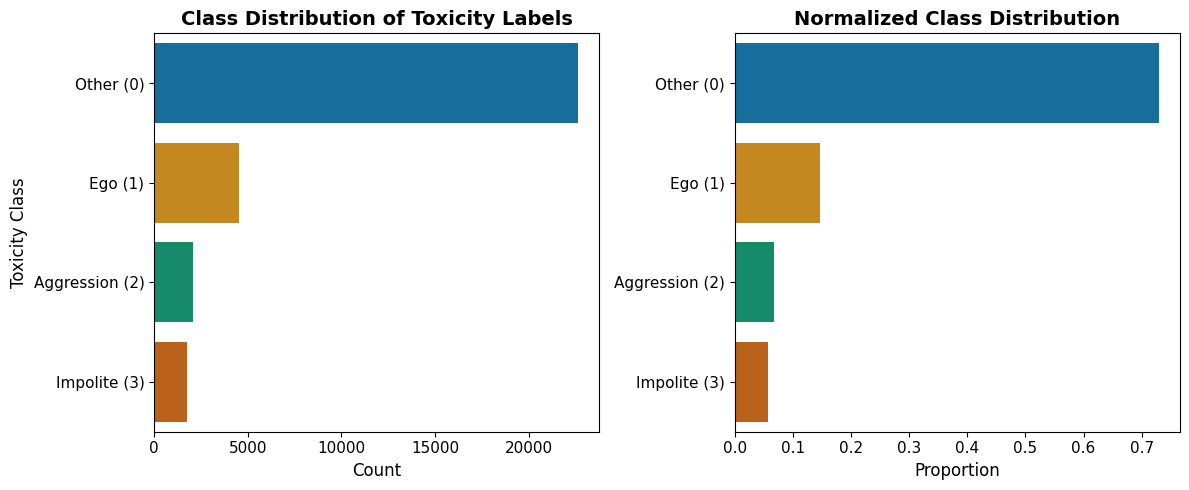

In [98]:
# distribution plot 
class_order_dota  = [0, 1, 2, 3]
class_labels_dota = ["Other (0)", "Ego (1)", "Aggression (2)", "Impolite (3)"]
label_map_dota    = dict(zip(class_order_dota, class_labels_dota))

dota["label_name"] = dota["label"].map(label_map_dota)

class_props = dota["label"].value_counts(normalize=True).reindex(class_order_dota)

# figure size 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot
sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Count", fontsize=12)
axes[0].set_ylabel("Toxicity Class", fontsize=12)
axes[0].tick_params(labelsize=11)

# second plot
sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Proportion", fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

The distribution of classes in dota dataset is less imbalanced, but there is still imbalance. We again need to think about potential merging of classes, changing goal to binary classification or testing against multi-classification.

#### Non-English Messages

Dota 2 is a globally played game - non-ASCII messages are common. We drop them since we are building an English-only classifier.

In [100]:
# count non-ASCII messages
non_english_count = dota["message"].str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum()
print(f"Number of non-ASCII messages: {non_english_count}")
print(f"Percentage of non-ASCII messages: {(non_english_count / len(dota)) * 100:.2f}%")

Number of non-ASCII messages: 290
Percentage of non-ASCII messages: 0.93%


In [101]:
# drop non-ASCII (non-English) messages
dota_english = dota[~dota["message"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)].copy()

print(f"Shape of English-only dataset: {dota_english.shape}")
print(dota_english.info())

Shape of English-only dataset: (30737, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 30737 entries, 0 to 31026
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       30737 non-null  int64 
 1   message     30737 non-null  object
 2   label       30737 non-null  int64 
 3   label_name  30737 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.2+ MB
None


#### Data Artifacts

In [102]:
# check for HTML entities
html_mask = dota_english["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities: {html_mask.sum()}")
dota_english[html_mask][["message", "label"]].head(10)

Messages with HTML entities: 0


,message,label


In [103]:
# decode HTML entities and check for any remaining
dota_english["message"] = dota_english["message"].apply(html_lib.unescape)

html_mask = dota_english["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities after decoding: {html_mask.sum()}")
print(f"Shape: {dota_english.shape}")

Messages with HTML entities after decoding: 0
Shape: (30737, 4)


In [105]:
# strip [SEPA] - it's a data collection artifact, not language
dota_english["message"] = dota_english["message"].str.replace(r"\s*\[SEPA\]\s*", " ", regex=True).str.strip()

# verify
sepa_remaining = dota_english["message"].str.contains(r"\[SEPA\]", regex=True, na=False).sum()
print(f"[SEPA] tokens remaining: {sepa_remaining}")

[SEPA] tokens remaining: 0


#### Word Frequency Analysis

In [106]:
# train/val split — stratified to preserve class proportions
X_dota = dota_english["message"]
y_dota = dota_english["label"]

X_dota_train, X_dota_val, y_dota_train, y_dota_val = train_test_split(
    X_dota, y_dota, test_size=0.20, random_state=seed, shuffle=True, stratify=y_dota
)

dota_train_df = pd.DataFrame({"message": X_dota_train, "label": y_dota_train}).reset_index(drop=True)
dota_val_df   = pd.DataFrame({"message": X_dota_val,   "label": y_dota_val}).reset_index(drop=True)

print(f"Train dataset shape: {dota_train_df.shape}")
print(f"Validation dataset shape: {dota_val_df.shape}")

Train dataset shape: (24589, 2)
Validation dataset shape: (6148, 2)


#### Number of words per document

In [107]:
# summary statistics of comment lengths
print("Summary statistics of comment lengths:")
dota_train_df["comment_length"] = dota_train_df["message"].str.split().str.len()
dota_train_df["comment_length"].describe()

Summary statistics of comment lengths:


count    24589.000000
mean         3.715808
std          3.340366
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         51.000000
Name: comment_length, dtype: float64

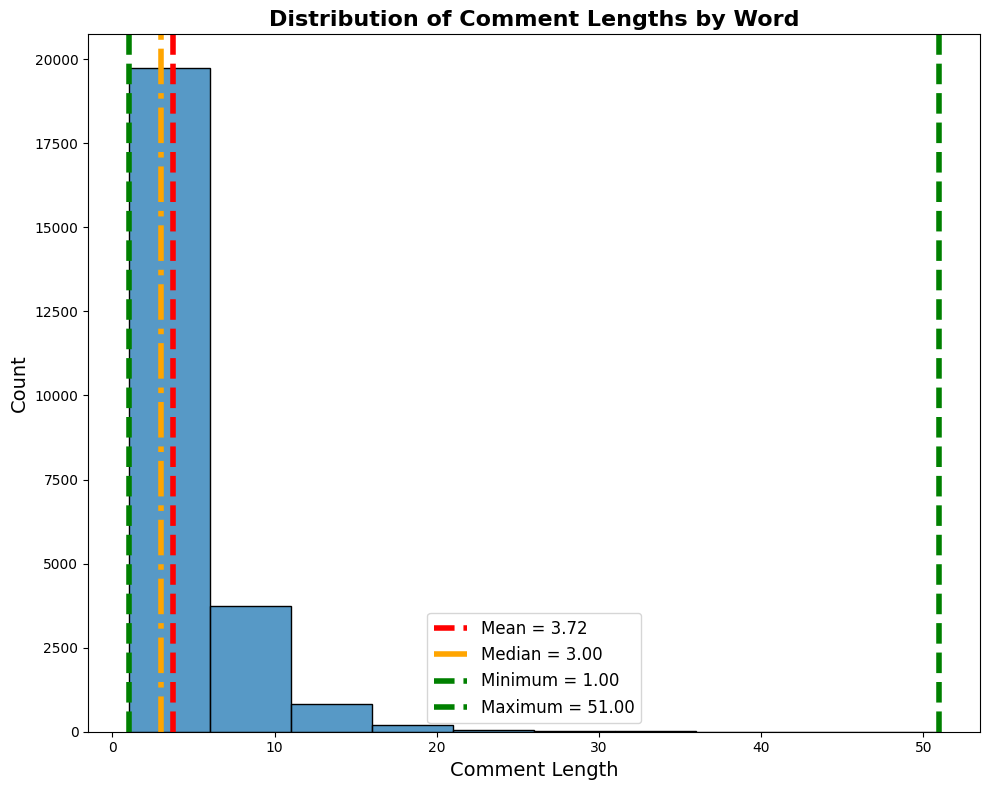

In [108]:
# distribution of comment lengths by word
mean_len   = dota_train_df["comment_length"].mean()
median_len = dota_train_df["comment_length"].median()
min_len    = dota_train_df["comment_length"].min()
max_len    = dota_train_df["comment_length"].max()

plt.figure(figsize=(10, 8))
sns.histplot(dota_train_df["comment_length"], bins=10, kde=False)

plt.axvline(mean_len,   linestyle="--", linewidth=4, label=f"Mean = {mean_len:.2f}",    color="red")
plt.axvline(median_len, linestyle="-.", linewidth=4, label=f"Median = {median_len:.2f}", color="orange")
plt.axvline(min_len,    linestyle="--", linewidth=4, label=f"Minimum = {min_len:.2f}",  color="green")
plt.axvline(max_len,    linestyle="--", linewidth=4, label=f"Maximum = {max_len:.2f}",  color="green")

plt.title("Distribution of Comment Lengths by Word", fontweight="bold", fontsize=16)
plt.xlabel("Comment Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Agai, we can see than mean and median number of words in each message is ~3. We will utilize unigrams/bigrams for dota dataset as well.

In [109]:
# comments longer than the median top 10 words
dota_train_df[dota_train_df["comment_length"] > median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
4,thanks for the heads up,5,0
6,LOL BAITED ITS WORKING WE ARE INFILTRATING,7,0
7,MY TEAM IS GOOD,4,0
14,hes a ghost lol,4,0
17,really? you guys didnt wait us,6,0
18,rs =)) spec noob,4,1
29,sk is a kid,4,3
35,13 minutes cm still level 3,6,3
41,we have best mid all time,6,0
44,wp husker i commend u,5,0


In [110]:
# comments longer than the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] > median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
24559,DID U KNOW U GUYS ARE SOOOO NOOOB?,8,1
24563,WTF IS UR PROBKME,4,1
24571,Zzzzz im sick with these puases srsly,7,3
24573,suck my cock friend,4,1
24574,easy cm tuskar you mad?,5,3
24576,Wait him respawn we pause ... god cant underst...,12,2
24579,DED EZ EZ EZ 2ez for me,7,3
24581,mvp 2-0'd them last time they played let alone...,11,0
24582,he is FUCKING DENDI COMPARED TO WHAT I HAVE IN...,17,1
24587,only doom did well,4,0


In [111]:
# comments shorter than the median top 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
2,so trolled,2,0
8,gg wp,2,0
9,yes ES,2,0
13,o0o,1,0
15,jaja,1,0
16,hf lanjiao,2,0
19,TT{_T},1,0
21,gg wp,2,0
22,>_<,1,0
23,:D,1,0


In [112]:
# comments shorter than the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
24572,COMMEND me,2,2
24575,CARRY!,1,0
24577,why me,2,0
24578,end guys,2,0
24580,))),1,0
24583,new year?,2,0
24584,noob wr,2,1
24585,WASTing time,2,1
24586,=),1,0
24588,retarded jug,2,1


Messages are extremely short - median 3 words, max ~30 in train data. Dota 2 chat mirrors WoT: reaction-driven, not conversational. This confirms unigram + bigram TF-IDF is the right choice - trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [113]:
# top 20 most frequent words in training set
all_text = " ".join(X_dota_train.astype(str))
words = all_text.split()

word_freq = pd.DataFrame(Counter(words).items(), columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)
word_freq.head(20)

,word,count
100,i,1259
101,u,1202
47,you,1085
29,gg,930
37,is,799
41,a,751
13,the,742
157,to,716
160,ez,701
57,me,698


In [179]:
# stopwords dictionary 
EXTRA = {
    # contractions
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve", "did",

    # pure filler
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",
    "xd", "lol", "omg", "thx", "sry", "hf",

    # Dota hero names only
    "abaddon", "alchemist", "axe", "bane", "batrider", "beastmaster",
    "bloodseeker", "brewmaster", "bristleback", "broodmother", "centaur",
    "chen", "clinkz", "clockwerk", "dazzle", "dawnbreaker", "disruptor",
    "doom", "enchantress", "enigma", "grimstroke", "gyrocopter", "hoodwink",
    "huskar", "invoker", "io", "jakiro", "juggernaut", "kunkka", "leshrac",
    "lich", "lifestealer", "lina", "lion", "luna", "lycan", "magnus",
    "marci", "mars", "medusa", "meepo", "mirana", "morphling", "muerta",
    "necrophos", "oracle", "pangolier", "phoenix", "puck", "pudge", "pugna",
    "razor", "riki", "rubick", "silencer", "slark", "slardar", "snapfire",
    "sniper", "spectre", "sven", "techies", "tidehunter", "timbersaw",
    "tinker", "tiny", "tusk", "underlord", "undying", "ursa", "viper",
    "visage", "warlock", "weaver", "zeus", "kez", "largo",

    # hero abbreviations
    "sf", "qop", "ta", "am", "es", "pa", "pl", "wk", "dk",
    "lc", "tb", "sk", "ns", "od", "wd", "sd", "ss", "kotl",
    "mk", "vs", "dp", "ck", "bh", "sb", "ember", "void", "storm",
    "jugg", "jug", "drow", "bara", "gyro", "legion", "rosh", "clock",
    "necro", "invo", "potm",

    # game mechanics with zero signal
    "ggwp", "mmr", "ff", "dc", "w8", "rc",
    "pause", "unpause", "commend", "commended",
    "reconnecting", "reconnect", "lag",
    "just", "like", "really", "guys", "know", "come",
    "want", "time", "got", "win", "play", "game",
    "end", "nice", "good", "wait", "pro", "wow",
    "haha", "rofl", "ty", "thanks", "said", "min",
    "sec", "wr", "need", "team", "afk", "comend"
}

# append with sklearn dictionary
STOPWORDS = list(ENGLISH_STOP_WORDS.union(EXTRA))
print(STOPWORDS)

['fifty', 'someone', 'sometimes', 'why', 'out', 'hundred', 'w8', 'yeah', 'thin', 'myself', 'wouldnt', 'own', 'necrophos', 'along', 'per', 'weaver', 'has', 'razor', 'marci', 'whose', 'bill', 'also', 'sk', 'formerly', 'together', 'storm', 'often', 'jugg', 'theyre', 'commended', 'gotta', 'ursa', 'here', 'fifteen', 'show', 'whenever', 'besides', 'sixty', 'bara', 'how', 'below', 'know', 'potm', 'gyrocopter', 'their', 'brewmaster', 'still', 'into', 'have', 'twenty', 'must', 'seem', 'hereupon', 'first', 'rofl', 'anyone', 'beside', 'afterwards', 'un', 'doesnt', 'themselves', 'necro', 'thanks', 'back', 'nine', 'who', 'then', 'our', 'under', 'um', 'inc', 'whether', 'ss', 'underlord', 'had', 'ever', 'because', 'bloodseeker', 'and', 'across', 'five', 'always', 'enough', 'somehow', 'made', 'wd', 'those', 'eg', 'end', 'your', 'should', 'ours', 'other', 'him', 'much', 'gonna', 'latter', 'some', 'lc', 'lycan', 'ten', 'whence', 'whither', 'juggernaut', 'are', 'wait', 'another', 'while', 'whole', 'witho

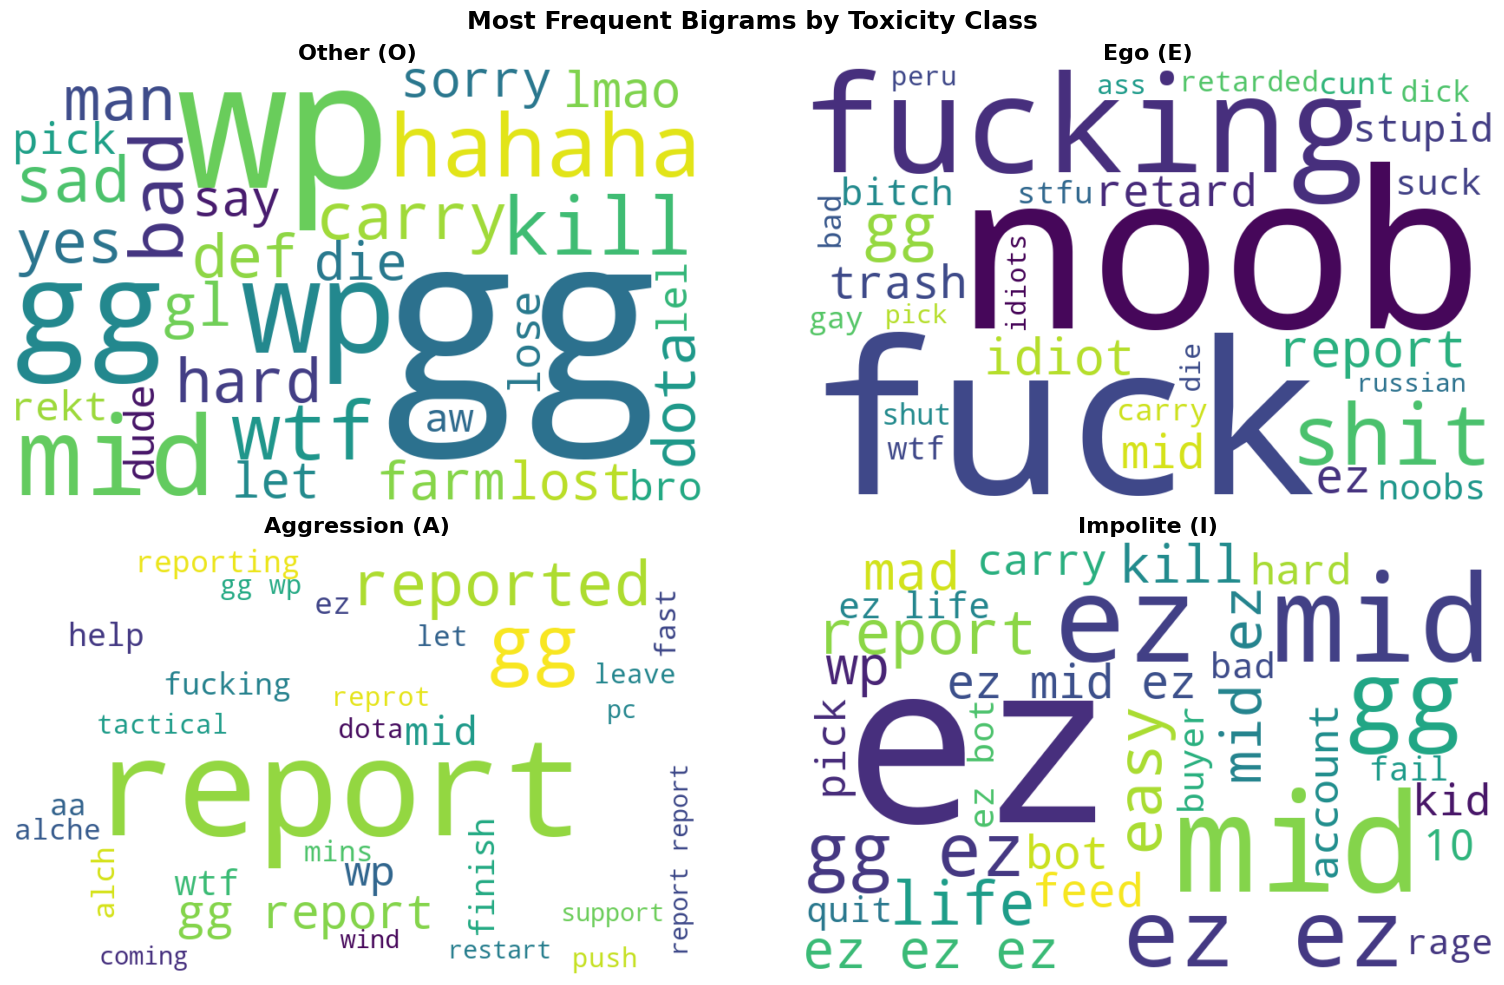

In [180]:
class_map_dota = {0: "Other (O)", 1: "Ego (E)", 2: "Aggression (A)", 3: "Impolite (I)"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(sorted(dota_train_df["label"].unique())):
    class_text = dota_train_df.loc[dota_train_df["label"] == cls, "message"].astype(str)

    bigram_vectorizer = CountVectorizer(
        strip_accents="unicode",
        lowercase=True,
        stop_words=STOPWORDS,
        max_df=0.90,
        ngram_range=(1, 3)
    )

    bigrams_train = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_train.sum(axis=0).A1
    bigram_names  = bigram_vectorizer.get_feature_names_out()

    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count":  bigram_counts
    }).sort_values(by="count", ascending=False).head(30)

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], bigram_freq_train["count"]))
        wordcloud = WordCloud(width=800, height=500, background_color="white").generate_from_frequencies(bigram_dict)
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)

plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Other (non-toxic) uses coordination language (gg, wp, nice). Ego centers on boasting and blame directed at teammates. Aggression uses direct insults and profanity. Impolite uses mild rudeness without explicit slurs - the most ambiguous class and hardest to distinguish from Ego.

- **Signals:**
    - Other (O): gg, wp, kill, carry, hard, bad, wtf - neutral game outcomes + sportsmanship

    - Ego (E): noob, fuck, fucking, shit, idiot, retard - skill attacks

    - Aggression (A): report, reported, reporting - behavior complaints dominate clearly

    - Impolite (I): ez, mid, easy, bot, life, kid, rage - condescension

### Pre-processing

Same TweetTokenizer pipeline as WoT - Dota 2 chat is structurally identical: short, informal, abbreviation-heavy. All-caps words (`REPORT`, `GG`) preserved for expressive intensity.

In [181]:
# apply same cleaner used for WoT
dota_train_df["clean_message"] = batch_clean(dota_train_df["message"].astype(str))
dota_val_df["clean_message"]   = batch_clean(dota_val_df["message"].astype(str))

print("Sample cleaned messages:")
dota_train_df["clean_message"].head(10)

Sample cleaned messages:


0                                  fu papa fear
1                                              
2                                         troll
3                                     noob fuck
4                                          head
5                                              
6    LOL BAITED ITS WORKING WE ARE INFILTRATING
7                               MY TEAM IS GOOD
8                                         gg wp
9                                        yes ES
Name: clean_message, dtype: object

#### Save Splits

In [183]:
# save splits to parquet
dota_train_df.to_parquet(DATA_DIR_DOTA / "dota_train_ml.parquet", index=False)
dota_val_df.to_parquet(DATA_DIR_DOTA / "dota_val_ml.parquet", index=False)

print("Saved:")
print(f"dota_train_ml.parquet — {dota_train_df.shape}")
print(f"dota_val_ml.parquet  — {dota_val_df.shape}")

Saved:
dota_train_ml.parquet — (24589, 4)
dota_val_ml.parquet  — (6148, 3)
